# Notebook 04 — Graph Modeling Neo4j

## Fraud Graph Analytics  
### Modelagem do Knowledge Graph para Prevenção a Fraudes Transacionais

Este notebook transforma as entidades, transações e alertas gerados nos notebooks anteriores em uma estrutura orientada a grafo, preparada para carga no Neo4j.

O objetivo é construir a camada de **Graph Modeling** do projeto, conectando:

- clientes;
- contas;
- transações;
- beneficiários;
- dispositivos;
- IPs;
- cartões;
- regras antifraude;
- alertas.

A modelagem em grafo permitirá investigar relações indiretas, padrões de compartilhamento, concentração de beneficiários, dispositivos críticos, contas conectadas e comunidades suspeitas.

## 1. Objetivo da Célula

### Objetivo

Configurar o ambiente inicial do notebook, carregar os dados sintéticos e os artefatos do motor de regras antifraude.

### Ações realizadas

- Importação das bibliotecas principais.
- Definição dos diretórios do projeto.
- Carregamento das entidades sintéticas.
- Carregamento da base transacional com score de regras.
- Carregamento dos alertas antifraude.
- Preparação dos diretórios de exportação para Neo4j.

### Justificativa técnica

O Neo4j exige uma estrutura clara de nós, relacionamentos, propriedades e constraints. Antes da carga, é necessário transformar os dados tabulares em arquivos de nós e arestas com chaves consistentes.

### Resultados esperados

Ambiente preparado para criação dos datasets de nós e relacionamentos do Knowledge Graph antifraude.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

In [3]:
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", "{:,.4f}".format)

In [4]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
GOLD_DIR = DATA_DIR / "03-gold"
NEO4J_IMPORT_DIR = GOLD_DIR / "neo4j_import"

DOCS_DIR = PROJECT_ROOT / "docs"
CYPHER_DIR = PROJECT_ROOT / "cypher"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"

NEO4J_IMPORT_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)
CYPHER_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:      {PROJECT_ROOT}")
print(f"Synthetic dir:     {SYNTHETIC_DIR}")
print(f"Gold dir:          {GOLD_DIR}")
print(f"Neo4j import dir:  {NEO4J_IMPORT_DIR}")
print(f"Cypher dir:        {CYPHER_DIR}")

Project root:      d:\_DS-Projects\Data-Science\fraud-graph-analytics
Synthetic dir:     d:\_DS-Projects\Data-Science\fraud-graph-analytics\data\synthetic
Gold dir:          d:\_DS-Projects\Data-Science\fraud-graph-analytics\data\03-gold
Neo4j import dir:  d:\_DS-Projects\Data-Science\fraud-graph-analytics\data\03-gold\neo4j_import
Cypher dir:        d:\_DS-Projects\Data-Science\fraud-graph-analytics\cypher


## 2. Carregamento dos Dados

Nesta etapa serão carregados os dados sintéticos gerados no Notebook 01 e os artefatos analíticos criados no Notebook 03.

Arquivos principais:

- `clientes.parquet`;
- `contas.parquet`;
- `dispositivos.parquet`;
- `ips.parquet`;
- `beneficiarios.parquet`;
- `cartoes.parquet`;
- `transacoes.parquet`;
- `transactions_with_rule_scores.parquet`;
- `antifraud_alerts.parquet`.

A base `transactions_with_rule_scores.parquet` será o principal insumo para conectar transações às regras antifraude.

In [5]:
synthetic_files = {
    "clientes": "clientes.parquet",
    "contas": "contas.parquet",
    "dispositivos": "dispositivos.parquet",
    "ips": "ips.parquet",
    "beneficiarios": "beneficiarios.parquet",
    "cartoes": "cartoes.parquet",
    "transacoes": "transacoes.parquet",
    "labels_fraude": "labels_fraude.parquet",
}

datasets = {}

for name, filename in synthetic_files.items():
    path = SYNTHETIC_DIR / filename
    
    if not path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {path}")
    
    datasets[name] = pd.read_parquet(path)

clientes = datasets["clientes"]
contas = datasets["contas"]
dispositivos = datasets["dispositivos"]
ips = datasets["ips"]
beneficiarios = datasets["beneficiarios"]
cartoes = datasets["cartoes"]
transacoes = datasets["transacoes"]
labels_fraude = datasets["labels_fraude"]

rules_scored_path = GOLD_DIR / "transactions_with_rule_scores.parquet"
alerts_path = GOLD_DIR / "antifraud_alerts.parquet"

if not rules_scored_path.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {rules_scored_path}. "
        "Execute o Notebook 03 antes de continuar."
    )

if not alerts_path.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {alerts_path}. "
        "Execute o Notebook 03 antes de continuar."
    )

rules_scored = pd.read_parquet(rules_scored_path)
alerts = pd.read_parquet(alerts_path)

print("Dados carregados com sucesso.")

Dados carregados com sucesso.


In [6]:
data_summary = pd.DataFrame(
    [
        {"dataset": "clientes", "linhas": len(clientes), "colunas": clientes.shape[1]},
        {"dataset": "contas", "linhas": len(contas), "colunas": contas.shape[1]},
        {"dataset": "dispositivos", "linhas": len(dispositivos), "colunas": dispositivos.shape[1]},
        {"dataset": "ips", "linhas": len(ips), "colunas": ips.shape[1]},
        {"dataset": "beneficiarios", "linhas": len(beneficiarios), "colunas": beneficiarios.shape[1]},
        {"dataset": "cartoes", "linhas": len(cartoes), "colunas": cartoes.shape[1]},
        {"dataset": "transacoes", "linhas": len(transacoes), "colunas": transacoes.shape[1]},
        {"dataset": "rules_scored", "linhas": len(rules_scored), "colunas": rules_scored.shape[1]},
        {"dataset": "alerts", "linhas": len(alerts), "colunas": alerts.shape[1]},
    ]
)

data_summary

,dataset,linhas,colunas
0,clientes,5000,6
1,contas,6000,6
2,dispositivos,4500,4
3,ips,3000,4
4,beneficiarios,3500,4
5,cartoes,4000,5
6,transacoes,80000,13
7,rules_scored,80000,82
8,alerts,79997,33


## 3. Modelo Conceitual do Grafo

O Knowledge Graph será estruturado com os seguintes tipos de nós:

| Label | Descrição |
|---|---|
| `Cliente` | Pessoa física simulada |
| `Conta` | Conta transacional |
| `Transacao` | Evento financeiro |
| `Beneficiario` | Recebedor da transação |
| `Dispositivo` | Dispositivo usado na operação |
| `IP` | Origem técnica da operação |
| `Cartao` | Cartão utilizado, quando aplicável |
| `Regra` | Regra antifraude acionada |

E os principais relacionamentos:

| Relacionamento | Descrição |
|---|---|
| `(:Cliente)-[:POSSUI]->(:Conta)` | Cliente possui conta |
| `(:Conta)-[:REALIZOU]->(:Transacao)` | Conta realizou transação |
| `(:Transacao)-[:ENVIOU_PARA]->(:Beneficiario)` | Transação enviada para beneficiário |
| `(:Transacao)-[:USOU]->(:Dispositivo)` | Transação usou dispositivo |
| `(:Transacao)-[:ORIGINOU_DE]->(:IP)` | Transação originada em IP |
| `(:Transacao)-[:UTILIZOU]->(:Cartao)` | Transação utilizou cartão |
| `(:Transacao)-[:ACIONOU]->(:Regra)` | Transação acionou regra antifraude |
| `(:Conta)-[:USOU_DISPOSITIVO]->(:Dispositivo)` | Relação agregada conta-dispositivo |
| `(:Conta)-[:ENVIOU_PARA_BENEFICIARIO]->(:Beneficiario)` | Relação agregada conta-beneficiário |
| `(:Conta)-[:USOU_IP]->(:IP)` | Relação agregada conta-IP |

## 4. Catálogo de Regras para o Grafo

As regras antifraude também serão representadas como nós no grafo.

Isso permite responder perguntas como:

- quais regras foram mais acionadas?
- quais transações acionaram múltiplas regras?
- quais contas estão conectadas a regras de alta severidade?
- quais cenários de fraude estão associados a cada regra?

In [7]:
rules_catalog = pd.DataFrame(
    [
        {
            "rule_id": "R001",
            "rule_flag": "R001_alto_valor_transacional",
            "rule_name": "alto_valor_transacional",
            "severidade": "media",
            "pontos": 15,
            "tipo_sinal": "valor",
        },
        {
            "rule_id": "R002",
            "rule_flag": "R002_valor_acima_limite_diario",
            "rule_name": "valor_acima_limite_diario",
            "severidade": "media",
            "pontos": 12,
            "tipo_sinal": "valor_limite",
        },
        {
            "rule_id": "R003",
            "rule_flag": "R003_conta_nova_alto_valor",
            "rule_name": "conta_nova_alto_valor",
            "severidade": "alta",
            "pontos": 22,
            "tipo_sinal": "conta",
        },
        {
            "rule_id": "R004",
            "rule_flag": "R004_dispositivo_compartilhado",
            "rule_name": "dispositivo_compartilhado",
            "severidade": "alta",
            "pontos": 20,
            "tipo_sinal": "device",
        },
        {
            "rule_id": "R005",
            "rule_flag": "R005_beneficiario_concentrador",
            "rule_name": "beneficiario_concentrador",
            "severidade": "alta",
            "pontos": 20,
            "tipo_sinal": "beneficiario",
        },
        {
            "rule_id": "R006",
            "rule_flag": "R006_rede_ou_device_alto_risco",
            "rule_name": "rede_ou_device_alto_risco",
            "severidade": "media",
            "pontos": 14,
            "tipo_sinal": "risco_tecnico",
        },
        {
            "rule_id": "R007",
            "rule_flag": "R007_rajada_transacional_horaria",
            "rule_name": "rajada_transacional_horaria",
            "severidade": "alta",
            "pontos": 22,
            "tipo_sinal": "velocidade",
        },
        {
            "rule_id": "R008",
            "rule_flag": "R008_muitos_beneficiarios_no_dia",
            "rule_name": "muitos_beneficiarios_no_dia",
            "severidade": "media",
            "pontos": 12,
            "tipo_sinal": "pulverizacao",
        },
        {
            "rule_id": "R009",
            "rule_flag": "R009_ip_compartilhado_multiplas_contas",
            "rule_name": "ip_compartilhado_multiplas_contas",
            "severidade": "media",
            "pontos": 12,
            "tipo_sinal": "ip",
        },
        {
            "rule_id": "R010",
            "rule_flag": "R010_canal_digital_alto_valor",
            "rule_name": "canal_digital_alto_valor",
            "severidade": "baixa",
            "pontos": 8,
            "tipo_sinal": "canal",
        },
    ]
)

rule_flag_columns = rules_catalog["rule_flag"].tolist()

rules_catalog

,rule_id,rule_flag,rule_name,severidade,pontos,tipo_sinal
0,R001,R001_alto_valor_transacional,alto_valor_transacional,media,15,valor
1,R002,R002_valor_acima_limite_diario,valor_acima_limite_diario,media,12,valor_limite
2,R003,R003_conta_nova_alto_valor,conta_nova_alto_valor,alta,22,conta
3,R004,R004_dispositivo_compartilhado,dispositivo_compartilhado,alta,20,device
4,R005,R005_beneficiario_concentrador,beneficiario_concentrador,alta,20,beneficiario
5,R006,R006_rede_ou_device_alto_risco,rede_ou_device_alto_risco,media,14,risco_tecnico
6,R007,R007_rajada_transacional_horaria,rajada_transacional_horaria,alta,22,velocidade
7,R008,R008_muitos_beneficiarios_no_dia,muitos_beneficiarios_no_dia,media,12,pulverizacao
8,R009,R009_ip_compartilhado_multiplas_contas,ip_compartilhado_multiplas_contas,media,12,ip
9,R010,R010_canal_digital_alto_valor,canal_digital_alto_valor,baixa,8,canal


## 5. Criação dos Nós do Grafo

Nesta etapa serão criadas tabelas específicas para cada tipo de nó.

Cada tabela terá um identificador único, propriedades relevantes e um label conceitual correspondente no Neo4j.

In [8]:
nodes_clientes = clientes[
    [
        "cliente_id",
        "idade",
        "uf",
        "segmento",
        "data_cadastro",
        "score_cadastral",
    ]
].drop_duplicates("cliente_id").copy()

nodes_contas = contas[
    [
        "conta_id",
        "cliente_id",
        "tipo_conta",
        "data_abertura",
        "status_conta",
        "limite_transacional_diario",
    ]
].drop_duplicates("conta_id").copy()

nodes_transacoes = rules_scored[
    [
        "transacao_id",
        "conta_origem_id",
        "beneficiario_id",
        "device_id",
        "ip_id",
        "cartao_id",
        "valor",
        "data_hora",
        "tipo_transacao",
        "canal",
        "status_transacao",
        "is_fraud",
        "fraud_scenario",
        "qtd_regras_acionadas",
        "rule_score",
        "risk_band",
        "alerta_gerado",
    ]
].drop_duplicates("transacao_id").copy()

nodes_beneficiarios = beneficiarios[
    [
        "beneficiario_id",
        "tipo_beneficiario",
        "banco_destino",
        "uf_destino",
    ]
].drop_duplicates("beneficiario_id").copy()

nodes_dispositivos = dispositivos[
    [
        "device_id",
        "tipo_device",
        "sistema_operacional",
        "fingerprint_risco",
    ]
].drop_duplicates("device_id").copy()

nodes_ips = ips[
    [
        "ip_id",
        "uf_origem",
        "tipo_rede",
        "risco_rede",
    ]
].drop_duplicates("ip_id").copy()

nodes_cartoes = cartoes[
    [
        "cartao_id",
        "conta_id",
        "tipo_cartao",
        "status_cartao",
        "data_emissao",
    ]
].drop_duplicates("cartao_id").copy()

nodes_regras = rules_catalog[
    [
        "rule_id",
        "rule_name",
        "severidade",
        "pontos",
        "tipo_sinal",
    ]
].drop_duplicates("rule_id").copy()

node_tables = {
    "nodes_clientes": nodes_clientes,
    "nodes_contas": nodes_contas,
    "nodes_transacoes": nodes_transacoes,
    "nodes_beneficiarios": nodes_beneficiarios,
    "nodes_dispositivos": nodes_dispositivos,
    "nodes_ips": nodes_ips,
    "nodes_cartoes": nodes_cartoes,
    "nodes_regras": nodes_regras,
}

node_summary = pd.DataFrame(
    [
        {"node_table": name, "linhas": len(df), "colunas": df.shape[1]}
        for name, df in node_tables.items()
    ]
)

node_summary

,node_table,linhas,colunas
0,nodes_clientes,5000,6
1,nodes_contas,6000,6
2,nodes_transacoes,80000,17
3,nodes_beneficiarios,3500,4
4,nodes_dispositivos,4500,4
5,nodes_ips,3000,4
6,nodes_cartoes,4000,5
7,nodes_regras,10,5


## 6. Criação dos Relacionamentos do Grafo

Nesta etapa serão criadas as tabelas de relacionamentos.

Serão construídos dois tipos de relação:

### Relações event-driven

Conectam transações aos seus elementos diretamente envolvidos:

- conta;
- beneficiário;
- dispositivo;
- IP;
- cartão;
- regras acionadas.

### Relações agregadas

Conectam entidades por padrões observados:

- conta-dispositivo;
- conta-beneficiário;
- conta-IP.

Essas relações agregadas são úteis para investigação e para futuras projeções de grafo.

In [9]:
rel_cliente_conta = (
    contas[["cliente_id", "conta_id"]]
    .dropna()
    .drop_duplicates()
    .copy()
)

rel_conta_transacao = (
    rules_scored[
        [
            "conta_origem_id",
            "transacao_id",
            "valor",
            "data_hora",
            "tipo_transacao",
            "canal",
            "rule_score",
            "risk_band",
            "alerta_gerado",
        ]
    ]
    .dropna(subset=["conta_origem_id", "transacao_id"])
    .drop_duplicates(["conta_origem_id", "transacao_id"])
    .copy()
)

rel_transacao_beneficiario = (
    rules_scored[
        [
            "transacao_id",
            "beneficiario_id",
            "valor",
            "data_hora",
            "tipo_transacao",
            "rule_score",
            "risk_band",
        ]
    ]
    .dropna(subset=["transacao_id", "beneficiario_id"])
    .drop_duplicates(["transacao_id", "beneficiario_id"])
    .copy()
)

rel_transacao_device = (
    rules_scored[
        [
            "transacao_id",
            "device_id",
            "data_hora",
            "tipo_transacao",
            "rule_score",
            "risk_band",
        ]
    ]
    .dropna(subset=["transacao_id", "device_id"])
    .drop_duplicates(["transacao_id", "device_id"])
    .copy()
)

rel_transacao_ip = (
    rules_scored[
        [
            "transacao_id",
            "ip_id",
            "data_hora",
            "tipo_transacao",
            "rule_score",
            "risk_band",
        ]
    ]
    .dropna(subset=["transacao_id", "ip_id"])
    .drop_duplicates(["transacao_id", "ip_id"])
    .copy()
)

rel_transacao_cartao = (
    rules_scored[
        [
            "transacao_id",
            "cartao_id",
            "data_hora",
            "tipo_transacao",
            "rule_score",
            "risk_band",
        ]
    ]
    .dropna(subset=["transacao_id", "cartao_id"])
    .drop_duplicates(["transacao_id", "cartao_id"])
    .copy()
)

display(rel_cliente_conta.head())
display(rel_conta_transacao.head())
display(rel_transacao_beneficiario.head())

,cliente_id,conta_id
0,CLI_004979,CTA_000001
1,CLI_004278,CTA_000002
2,CLI_002410,CTA_000003
3,CLI_001673,CTA_000004
4,CLI_002338,CTA_000005


,conta_origem_id,transacao_id,valor,data_hora,tipo_transacao,canal,rule_score,risk_band,alerta_gerado
0,CTA_001877,TX_00007707,203.3000,2025-01-01 03:05:51,pix,app,46,alto,True
1,CTA_003365,TX_00072064,275.9900,2025-01-01 03:13:25,pix,app,32,medio,True
2,CTA_000156,TX_00075764,11.5900,2025-01-01 04:00:23,pix,app,52,alto,True
3,CTA_005491,TX_00023203,296.9700,2025-01-01 04:08:36,pix,app,32,medio,True
4,CTA_000997,TX_00001302,94.9800,2025-01-01 04:15:04,boleto,api,52,alto,True


,transacao_id,beneficiario_id,valor,data_hora,tipo_transacao,rule_score,risk_band
0,TX_00007707,BEN_003322,203.3000,2025-01-01 03:05:51,pix,46,alto
1,TX_00072064,BEN_000265,275.9900,2025-01-01 03:13:25,pix,32,medio
2,TX_00075764,BEN_002832,11.5900,2025-01-01 04:00:23,pix,52,alto
3,TX_00023203,BEN_001801,296.9700,2025-01-01 04:08:36,pix,32,medio
4,TX_00001302,BEN_002808,94.9800,2025-01-01 04:15:04,boleto,52,alto


In [10]:
triggered_rule_edges = []

for _, rule in rules_catalog.iterrows():
    flag_col = rule["rule_flag"]
    
    if flag_col not in rules_scored.columns:
        continue
    
    temp = (
        rules_scored
        .loc[rules_scored[flag_col] == True, ["transacao_id", "rule_score", "risk_band", "fraud_scenario"]]
        .copy()
    )
    
    temp["rule_id"] = rule["rule_id"]
    temp["rule_name"] = rule["rule_name"]
    temp["pontos_regra"] = rule["pontos"]
    temp["severidade"] = rule["severidade"]
    
    triggered_rule_edges.append(temp)

rel_transacao_regra = pd.concat(triggered_rule_edges, ignore_index=True)

rel_transacao_regra = rel_transacao_regra[
    [
        "transacao_id",
        "rule_id",
        "rule_name",
        "pontos_regra",
        "severidade",
        "rule_score",
        "risk_band",
        "fraud_scenario",
    ]
].drop_duplicates(["transacao_id", "rule_id"])

rel_transacao_regra.head()

,transacao_id,rule_id,rule_name,pontos_regra,severidade,rule_score,risk_band,fraud_scenario
0,TX_00020042,R001,alto_valor_transacional,15,media,100,critico,new_account_high_value
1,TX_00070413,R001,alto_valor_transacional,15,media,100,critico,bridge_account
2,TX_00066795,R001,alto_valor_transacional,15,media,81,critico,normal
3,TX_00039727,R001,alto_valor_transacional,15,media,100,critico,coordinated_network
4,TX_00006840,R001,alto_valor_transacional,15,media,100,critico,coordinated_network


In [11]:
rel_conta_device_agg = (
    rules_scored
    .groupby(["conta_origem_id", "device_id"])
    .agg(
        qtd_transacoes=("transacao_id", "count"),
        valor_total=("valor", "sum"),
        valor_medio=("valor", "mean"),
        score_max=("rule_score", "max"),
        score_medio=("rule_score", "mean"),
        taxa_fraude_sintetica=("is_fraud", "mean"),
        qtd_alertas=("alerta_gerado", "sum"),
    )
    .reset_index()
)

rel_conta_beneficiario_agg = (
    rules_scored
    .groupby(["conta_origem_id", "beneficiario_id"])
    .agg(
        qtd_transacoes=("transacao_id", "count"),
        valor_total=("valor", "sum"),
        valor_medio=("valor", "mean"),
        score_max=("rule_score", "max"),
        score_medio=("rule_score", "mean"),
        taxa_fraude_sintetica=("is_fraud", "mean"),
        qtd_alertas=("alerta_gerado", "sum"),
    )
    .reset_index()
)

rel_conta_ip_agg = (
    rules_scored
    .groupby(["conta_origem_id", "ip_id"])
    .agg(
        qtd_transacoes=("transacao_id", "count"),
        valor_total=("valor", "sum"),
        valor_medio=("valor", "mean"),
        score_max=("rule_score", "max"),
        score_medio=("rule_score", "mean"),
        taxa_fraude_sintetica=("is_fraud", "mean"),
        qtd_alertas=("alerta_gerado", "sum"),
    )
    .reset_index()
)

display(rel_conta_device_agg.head())
display(rel_conta_beneficiario_agg.head())
display(rel_conta_ip_agg.head())

,conta_origem_id,device_id,qtd_transacoes,valor_total,valor_medio,score_max,score_medio,taxa_fraude_sintetica,qtd_alertas
0,CTA_000001,DEV_000478,1,631.7400,631.7400,32,32.0000,0.0000,1
1,CTA_000001,DEV_000789,1,104.0900,104.0900,32,32.0000,0.0000,1
2,CTA_000001,DEV_001310,1,232.7600,232.7600,32,32.0000,0.0000,1
3,CTA_000001,DEV_001330,1,385.0600,385.0600,52,52.0000,0.0000,1
4,CTA_000001,DEV_001375,1,184.2000,184.2000,52,52.0000,0.0000,1


,conta_origem_id,beneficiario_id,qtd_transacoes,valor_total,valor_medio,score_max,score_medio,taxa_fraude_sintetica,qtd_alertas
0,CTA_000001,BEN_000122,1,385.0600,385.0600,52,52.0000,0.0000,1
1,CTA_000001,BEN_000207,1,73.0000,73.0000,32,32.0000,0.0000,1
2,CTA_000001,BEN_000323,1,516.5200,516.5200,52,52.0000,0.0000,1
3,CTA_000001,BEN_000332,1,184.2000,184.2000,52,52.0000,0.0000,1
4,CTA_000001,BEN_000452,1,409.2800,409.2800,52,52.0000,0.0000,1


,conta_origem_id,ip_id,qtd_transacoes,valor_total,valor_medio,score_max,score_medio,taxa_fraude_sintetica,qtd_alertas
0,CTA_000001,IP_000123,1,385.0600,385.0600,52,52.0000,0.0000,1
1,CTA_000001,IP_000186,1,73.0000,73.0000,32,32.0000,0.0000,1
2,CTA_000001,IP_000447,1,409.2800,409.2800,52,52.0000,0.0000,1
3,CTA_000001,IP_000541,1,232.7600,232.7600,32,32.0000,0.0000,1
4,CTA_000001,IP_000919,1,510.6600,510.6600,32,32.0000,0.0000,1


In [12]:
relationship_tables = {
    "rel_cliente_conta": rel_cliente_conta,
    "rel_conta_transacao": rel_conta_transacao,
    "rel_transacao_beneficiario": rel_transacao_beneficiario,
    "rel_transacao_device": rel_transacao_device,
    "rel_transacao_ip": rel_transacao_ip,
    "rel_transacao_cartao": rel_transacao_cartao,
    "rel_transacao_regra": rel_transacao_regra,
    "rel_conta_device_agg": rel_conta_device_agg,
    "rel_conta_beneficiario_agg": rel_conta_beneficiario_agg,
    "rel_conta_ip_agg": rel_conta_ip_agg,
}

relationship_summary = pd.DataFrame(
    [
        {"relationship_table": name, "linhas": len(df), "colunas": df.shape[1]}
        for name, df in relationship_tables.items()
    ]
)

relationship_summary

,relationship_table,linhas,colunas
0,rel_cliente_conta,6000,2
1,rel_conta_transacao,80000,9
2,rel_transacao_beneficiario,80000,7
3,rel_transacao_device,80000,6
4,rel_transacao_ip,80000,6
5,rel_transacao_cartao,6278,6
6,rel_transacao_regra,221277,8
7,rel_conta_device_agg,79329,9
8,rel_conta_beneficiario_agg,79411,9
9,rel_conta_ip_agg,79326,9


## 7. Exportação dos CSVs para Neo4j

O Neo4j pode carregar dados a partir de arquivos CSV usando `LOAD CSV`.

Neste notebook, os arquivos serão exportados para:

`data/03-gold/neo4j_import/`

Para executar os scripts `LOAD CSV` dentro do Neo4j, será necessário copiar esses arquivos para a pasta `import` da instância Neo4j ou configurar o caminho de importação no ambiente utilizado.

In [13]:
def prepare_for_neo4j_csv(df: pd.DataFrame) -> pd.DataFrame:
    prepared = df.copy()
    
    for col in prepared.columns:
        if pd.api.types.is_datetime64_any_dtype(prepared[col]):
            prepared[col] = prepared[col].dt.strftime("%Y-%m-%dT%H:%M:%S")
        
        elif pd.api.types.is_bool_dtype(prepared[col]):
            prepared[col] = prepared[col].map({True: "true", False: "false"})
        
        elif prepared[col].dtype == "object":
            prepared[col] = prepared[col].astype("string")
    
    prepared = prepared.replace({pd.NA: "", np.nan: "", None: ""})
    
    return prepared


csv_exports = {}

for name, df in node_tables.items():
    output_path = NEO4J_IMPORT_DIR / f"{name}.csv"
    prepare_for_neo4j_csv(df).to_csv(output_path, index=False, encoding="utf-8")
    csv_exports[name] = output_path

for name, df in relationship_tables.items():
    output_path = NEO4J_IMPORT_DIR / f"{name}.csv"
    prepare_for_neo4j_csv(df).to_csv(output_path, index=False, encoding="utf-8")
    csv_exports[name] = output_path

print("Arquivos CSV exportados para Neo4j:")
for name, path in csv_exports.items():
    print(f"- {name}: {path.name}")

Arquivos CSV exportados para Neo4j:
- nodes_clientes: nodes_clientes.csv
- nodes_contas: nodes_contas.csv
- nodes_transacoes: nodes_transacoes.csv
- nodes_beneficiarios: nodes_beneficiarios.csv
- nodes_dispositivos: nodes_dispositivos.csv
- nodes_ips: nodes_ips.csv
- nodes_cartoes: nodes_cartoes.csv
- nodes_regras: nodes_regras.csv
- rel_cliente_conta: rel_cliente_conta.csv
- rel_conta_transacao: rel_conta_transacao.csv
- rel_transacao_beneficiario: rel_transacao_beneficiario.csv
- rel_transacao_device: rel_transacao_device.csv
- rel_transacao_ip: rel_transacao_ip.csv
- rel_transacao_cartao: rel_transacao_cartao.csv
- rel_transacao_regra: rel_transacao_regra.csv
- rel_conta_device_agg: rel_conta_device_agg.csv
- rel_conta_beneficiario_agg: rel_conta_beneficiario_agg.csv
- rel_conta_ip_agg: rel_conta_ip_agg.csv


## 8. Geração dos Scripts Cypher

Nesta etapa serão gerados scripts Cypher para:

1. criação de constraints e índices;
2. carga dos nós;
3. carga dos relacionamentos;
4. consultas investigativas iniciais.

Os scripts serão salvos na pasta `cypher/`.

In [14]:
constraints_cypher = """
CREATE CONSTRAINT cliente_id_unique IF NOT EXISTS
FOR (n:Cliente) REQUIRE n.cliente_id IS UNIQUE;

CREATE CONSTRAINT conta_id_unique IF NOT EXISTS
FOR (n:Conta) REQUIRE n.conta_id IS UNIQUE;

CREATE CONSTRAINT transacao_id_unique IF NOT EXISTS
FOR (n:Transacao) REQUIRE n.transacao_id IS UNIQUE;

CREATE CONSTRAINT beneficiario_id_unique IF NOT EXISTS
FOR (n:Beneficiario) REQUIRE n.beneficiario_id IS UNIQUE;

CREATE CONSTRAINT device_id_unique IF NOT EXISTS
FOR (n:Dispositivo) REQUIRE n.device_id IS UNIQUE;

CREATE CONSTRAINT ip_id_unique IF NOT EXISTS
FOR (n:IP) REQUIRE n.ip_id IS UNIQUE;

CREATE CONSTRAINT cartao_id_unique IF NOT EXISTS
FOR (n:Cartao) REQUIRE n.cartao_id IS UNIQUE;

CREATE CONSTRAINT regra_id_unique IF NOT EXISTS
FOR (n:Regra) REQUIRE n.rule_id IS UNIQUE;

CREATE INDEX transacao_risk_band IF NOT EXISTS
FOR (n:Transacao) ON (n.risk_band);

CREATE INDEX transacao_rule_score IF NOT EXISTS
FOR (n:Transacao) ON (n.rule_score);

CREATE INDEX regra_severidade IF NOT EXISTS
FOR (n:Regra) ON (n.severidade);
""".strip()

constraints_path = CYPHER_DIR / "01_constraints_indexes.cypher"
constraints_path.write_text(constraints_cypher, encoding="utf-8")

print(f"Script salvo em: {constraints_path}")

Script salvo em: d:\_DS-Projects\Data-Science\fraud-graph-analytics\cypher\01_constraints_indexes.cypher


In [15]:
load_nodes_cypher = """
// Clientes
LOAD CSV WITH HEADERS FROM 'file:///nodes_clientes.csv' AS row
MERGE (n:Cliente {cliente_id: row.cliente_id})
SET
    n.idade = toInteger(row.idade),
    n.uf = row.uf,
    n.segmento = row.segmento,
    n.data_cadastro = date(row.data_cadastro),
    n.score_cadastral = toInteger(row.score_cadastral);

// Contas
LOAD CSV WITH HEADERS FROM 'file:///nodes_contas.csv' AS row
MERGE (n:Conta {conta_id: row.conta_id})
SET
    n.cliente_id = row.cliente_id,
    n.tipo_conta = row.tipo_conta,
    n.data_abertura = date(row.data_abertura),
    n.status_conta = row.status_conta,
    n.limite_transacional_diario = toFloat(row.limite_transacional_diario);

// Transações
LOAD CSV WITH HEADERS FROM 'file:///nodes_transacoes.csv' AS row
MERGE (n:Transacao {transacao_id: row.transacao_id})
SET
    n.conta_origem_id = row.conta_origem_id,
    n.beneficiario_id = row.beneficiario_id,
    n.device_id = row.device_id,
    n.ip_id = row.ip_id,
    n.cartao_id = row.cartao_id,
    n.valor = toFloat(row.valor),
    n.data_hora = datetime(row.data_hora),
    n.tipo_transacao = row.tipo_transacao,
    n.canal = row.canal,
    n.status_transacao = row.status_transacao,
    n.is_fraud = toBoolean(row.is_fraud),
    n.fraud_scenario = row.fraud_scenario,
    n.qtd_regras_acionadas = toInteger(row.qtd_regras_acionadas),
    n.rule_score = toFloat(row.rule_score),
    n.risk_band = row.risk_band,
    n.alerta_gerado = toBoolean(row.alerta_gerado);

// Beneficiários
LOAD CSV WITH HEADERS FROM 'file:///nodes_beneficiarios.csv' AS row
MERGE (n:Beneficiario {beneficiario_id: row.beneficiario_id})
SET
    n.tipo_beneficiario = row.tipo_beneficiario,
    n.banco_destino = row.banco_destino,
    n.uf_destino = row.uf_destino;

// Dispositivos
LOAD CSV WITH HEADERS FROM 'file:///nodes_dispositivos.csv' AS row
MERGE (n:Dispositivo {device_id: row.device_id})
SET
    n.tipo_device = row.tipo_device,
    n.sistema_operacional = row.sistema_operacional,
    n.fingerprint_risco = row.fingerprint_risco;

// IPs
LOAD CSV WITH HEADERS FROM 'file:///nodes_ips.csv' AS row
MERGE (n:IP {ip_id: row.ip_id})
SET
    n.uf_origem = row.uf_origem,
    n.tipo_rede = row.tipo_rede,
    n.risco_rede = row.risco_rede;

// Cartões
LOAD CSV WITH HEADERS FROM 'file:///nodes_cartoes.csv' AS row
MERGE (n:Cartao {cartao_id: row.cartao_id})
SET
    n.conta_id = row.conta_id,
    n.tipo_cartao = row.tipo_cartao,
    n.status_cartao = row.status_cartao,
    n.data_emissao = date(row.data_emissao);

// Regras
LOAD CSV WITH HEADERS FROM 'file:///nodes_regras.csv' AS row
MERGE (n:Regra {rule_id: row.rule_id})
SET
    n.rule_name = row.rule_name,
    n.severidade = row.severidade,
    n.pontos = toInteger(row.pontos),
    n.tipo_sinal = row.tipo_sinal;
""".strip()

load_nodes_path = CYPHER_DIR / "02_load_nodes.cypher"
load_nodes_path.write_text(load_nodes_cypher, encoding="utf-8")

print(f"Script salvo em: {load_nodes_path}")

Script salvo em: d:\_DS-Projects\Data-Science\fraud-graph-analytics\cypher\02_load_nodes.cypher


In [16]:
load_relationships_cypher = """
// Cliente possui Conta
LOAD CSV WITH HEADERS FROM 'file:///rel_cliente_conta.csv' AS row
MATCH (c:Cliente {cliente_id: row.cliente_id})
MATCH (a:Conta {conta_id: row.conta_id})
MERGE (c)-[:POSSUI]->(a);

// Conta realizou Transação
LOAD CSV WITH HEADERS FROM 'file:///rel_conta_transacao.csv' AS row
MATCH (a:Conta {conta_id: row.conta_origem_id})
MATCH (t:Transacao {transacao_id: row.transacao_id})
MERGE (a)-[r:REALIZOU]->(t)
SET
    r.valor = toFloat(row.valor),
    r.data_hora = datetime(row.data_hora),
    r.tipo_transacao = row.tipo_transacao,
    r.canal = row.canal,
    r.rule_score = toFloat(row.rule_score),
    r.risk_band = row.risk_band,
    r.alerta_gerado = toBoolean(row.alerta_gerado);

// Transação enviada para Beneficiário
LOAD CSV WITH HEADERS FROM 'file:///rel_transacao_beneficiario.csv' AS row
MATCH (t:Transacao {transacao_id: row.transacao_id})
MATCH (b:Beneficiario {beneficiario_id: row.beneficiario_id})
MERGE (t)-[r:ENVIOU_PARA]->(b)
SET
    r.valor = toFloat(row.valor),
    r.data_hora = datetime(row.data_hora),
    r.tipo_transacao = row.tipo_transacao,
    r.rule_score = toFloat(row.rule_score),
    r.risk_band = row.risk_band;

// Transação usou Dispositivo
LOAD CSV WITH HEADERS FROM 'file:///rel_transacao_device.csv' AS row
MATCH (t:Transacao {transacao_id: row.transacao_id})
MATCH (d:Dispositivo {device_id: row.device_id})
MERGE (t)-[r:USOU]->(d)
SET
    r.data_hora = datetime(row.data_hora),
    r.tipo_transacao = row.tipo_transacao,
    r.rule_score = toFloat(row.rule_score),
    r.risk_band = row.risk_band;

// Transação originou de IP
LOAD CSV WITH HEADERS FROM 'file:///rel_transacao_ip.csv' AS row
MATCH (t:Transacao {transacao_id: row.transacao_id})
MATCH (ip:IP {ip_id: row.ip_id})
MERGE (t)-[r:ORIGINOU_DE]->(ip)
SET
    r.data_hora = datetime(row.data_hora),
    r.tipo_transacao = row.tipo_transacao,
    r.rule_score = toFloat(row.rule_score),
    r.risk_band = row.risk_band;

// Transação utilizou Cartão
LOAD CSV WITH HEADERS FROM 'file:///rel_transacao_cartao.csv' AS row
MATCH (t:Transacao {transacao_id: row.transacao_id})
MATCH (c:Cartao {cartao_id: row.cartao_id})
MERGE (t)-[r:UTILIZOU]->(c)
SET
    r.data_hora = datetime(row.data_hora),
    r.tipo_transacao = row.tipo_transacao,
    r.rule_score = toFloat(row.rule_score),
    r.risk_band = row.risk_band;

// Transação acionou Regra
LOAD CSV WITH HEADERS FROM 'file:///rel_transacao_regra.csv' AS row
MATCH (t:Transacao {transacao_id: row.transacao_id})
MATCH (reg:Regra {rule_id: row.rule_id})
MERGE (t)-[r:ACIONOU]->(reg)
SET
    r.rule_name = row.rule_name,
    r.pontos_regra = toInteger(row.pontos_regra),
    r.severidade = row.severidade,
    r.rule_score = toFloat(row.rule_score),
    r.risk_band = row.risk_band,
    r.fraud_scenario = row.fraud_scenario;

// Relação agregada Conta-Dispositivo
LOAD CSV WITH HEADERS FROM 'file:///rel_conta_device_agg.csv' AS row
MATCH (a:Conta {conta_id: row.conta_origem_id})
MATCH (d:Dispositivo {device_id: row.device_id})
MERGE (a)-[r:USOU_DISPOSITIVO]->(d)
SET
    r.qtd_transacoes = toInteger(row.qtd_transacoes),
    r.valor_total = toFloat(row.valor_total),
    r.valor_medio = toFloat(row.valor_medio),
    r.score_max = toFloat(row.score_max),
    r.score_medio = toFloat(row.score_medio),
    r.taxa_fraude_sintetica = toFloat(row.taxa_fraude_sintetica),
    r.qtd_alertas = toInteger(row.qtd_alertas);

// Relação agregada Conta-Beneficiário
LOAD CSV WITH HEADERS FROM 'file:///rel_conta_beneficiario_agg.csv' AS row
MATCH (a:Conta {conta_id: row.conta_origem_id})
MATCH (b:Beneficiario {beneficiario_id: row.beneficiario_id})
MERGE (a)-[r:ENVIOU_PARA_BENEFICIARIO]->(b)
SET
    r.qtd_transacoes = toInteger(row.qtd_transacoes),
    r.valor_total = toFloat(row.valor_total),
    r.valor_medio = toFloat(row.valor_medio),
    r.score_max = toFloat(row.score_max),
    r.score_medio = toFloat(row.score_medio),
    r.taxa_fraude_sintetica = toFloat(row.taxa_fraude_sintetica),
    r.qtd_alertas = toInteger(row.qtd_alertas);

// Relação agregada Conta-IP
LOAD CSV WITH HEADERS FROM 'file:///rel_conta_ip_agg.csv' AS row
MATCH (a:Conta {conta_id: row.conta_origem_id})
MATCH (ip:IP {ip_id: row.ip_id})
MERGE (a)-[r:USOU_IP]->(ip)
SET
    r.qtd_transacoes = toInteger(row.qtd_transacoes),
    r.valor_total = toFloat(row.valor_total),
    r.valor_medio = toFloat(row.valor_medio),
    r.score_max = toFloat(row.score_max),
    r.score_medio = toFloat(row.score_medio),
    r.taxa_fraude_sintetica = toFloat(row.taxa_fraude_sintetica),
    r.qtd_alertas = toInteger(row.qtd_alertas);
""".strip()

load_relationships_path = CYPHER_DIR / "03_load_relationships.cypher"
load_relationships_path.write_text(load_relationships_cypher, encoding="utf-8")

print(f"Script salvo em: {load_relationships_path}")

Script salvo em: d:\_DS-Projects\Data-Science\fraud-graph-analytics\cypher\03_load_relationships.cypher


In [17]:
investigation_queries_cypher = """
// 1. Top transações críticas
MATCH (t:Transacao)
WHERE t.risk_band = 'critico'
RETURN
    t.transacao_id AS transacao_id,
    t.valor AS valor,
    t.rule_score AS rule_score,
    t.fraud_scenario AS fraud_scenario,
    t.qtd_regras_acionadas AS qtd_regras_acionadas
ORDER BY t.rule_score DESC, t.valor DESC
LIMIT 25;

// 2. Beneficiários concentradores por quantidade de contas de origem
MATCH (a:Conta)-[r:ENVIOU_PARA_BENEFICIARIO]->(b:Beneficiario)
RETURN
    b.beneficiario_id AS beneficiario_id,
    count(DISTINCT a) AS contas_origem,
    sum(r.qtd_transacoes) AS qtd_transacoes,
    sum(r.valor_total) AS valor_total,
    avg(r.score_medio) AS score_medio
ORDER BY contas_origem DESC, valor_total DESC
LIMIT 25;

// 3. Dispositivos compartilhados por múltiplas contas
MATCH (a:Conta)-[r:USOU_DISPOSITIVO]->(d:Dispositivo)
RETURN
    d.device_id AS device_id,
    d.fingerprint_risco AS fingerprint_risco,
    count(DISTINCT a) AS contas_distintas,
    sum(r.qtd_transacoes) AS qtd_transacoes,
    sum(r.qtd_alertas) AS qtd_alertas,
    avg(r.score_medio) AS score_medio
ORDER BY contas_distintas DESC, qtd_alertas DESC
LIMIT 25;

// 4. IPs usados por múltiplas contas
MATCH (a:Conta)-[r:USOU_IP]->(ip:IP)
RETURN
    ip.ip_id AS ip_id,
    ip.risco_rede AS risco_rede,
    ip.tipo_rede AS tipo_rede,
    count(DISTINCT a) AS contas_distintas,
    sum(r.qtd_transacoes) AS qtd_transacoes,
    sum(r.qtd_alertas) AS qtd_alertas,
    avg(r.score_medio) AS score_medio
ORDER BY contas_distintas DESC, qtd_alertas DESC
LIMIT 25;

// 5. Regras mais acionadas
MATCH (t:Transacao)-[r:ACIONOU]->(reg:Regra)
RETURN
    reg.rule_id AS rule_id,
    reg.rule_name AS rule_name,
    reg.severidade AS severidade,
    count(DISTINCT t) AS qtd_transacoes,
    avg(t.rule_score) AS score_medio,
    count(DISTINCT t.fraud_scenario) AS qtd_cenarios
ORDER BY qtd_transacoes DESC
LIMIT 25;

// 6. Caminho investigativo de uma transação crítica
MATCH path = (a:Conta)-[:REALIZOU]->(t:Transacao)-[:ENVIOU_PARA|USOU|ORIGINOU_DE|ACIONOU]->(n)
WHERE t.risk_band = 'critico'
RETURN path
LIMIT 25;

// 7. Contas com múltiplas conexões suspeitas
MATCH (a:Conta)
OPTIONAL MATCH (a)-[rd:USOU_DISPOSITIVO]->(d:Dispositivo)
OPTIONAL MATCH (a)-[rb:ENVIOU_PARA_BENEFICIARIO]->(b:Beneficiario)
OPTIONAL MATCH (a)-[ri:USOU_IP]->(ip:IP)
RETURN
    a.conta_id AS conta_id,
    count(DISTINCT d) AS dispositivos,
    count(DISTINCT b) AS beneficiarios,
    count(DISTINCT ip) AS ips,
    sum(coalesce(rd.qtd_alertas, 0)) + sum(coalesce(rb.qtd_alertas, 0)) + sum(coalesce(ri.qtd_alertas, 0)) AS sinais_alerta
ORDER BY sinais_alerta DESC
LIMIT 25;
""".strip()

investigation_queries_path = CYPHER_DIR / "04_fraud_investigation_queries.cypher"
investigation_queries_path.write_text(investigation_queries_cypher, encoding="utf-8")

print(f"Script salvo em: {investigation_queries_path}")

Script salvo em: d:\_DS-Projects\Data-Science\fraud-graph-analytics\cypher\04_fraud_investigation_queries.cypher


In [18]:
gds_queries_cypher = """
// Projeção sugerida para o próximo notebook.
//
// Observação:
// O Notebook 05 será dedicado a Graph Data Science.
// As queries abaixo são um ponto de partida para projeções futuras.

// Exemplo conceitual de projeção Conta-Dispositivo-Beneficiário-IP
// Ajustar conforme versão instalada do Neo4j GDS.

CALL gds.graph.project(
    'fraud_graph_bipartite',
    ['Conta', 'Dispositivo', 'Beneficiario', 'IP'],
    {
        USOU_DISPOSITIVO: {
            type: 'USOU_DISPOSITIVO',
            orientation: 'UNDIRECTED',
            properties: ['qtd_alertas', 'score_medio', 'valor_total']
        },
        ENVIOU_PARA_BENEFICIARIO: {
            type: 'ENVIOU_PARA_BENEFICIARIO',
            orientation: 'UNDIRECTED',
            properties: ['qtd_alertas', 'score_medio', 'valor_total']
        },
        USOU_IP: {
            type: 'USOU_IP',
            orientation: 'UNDIRECTED',
            properties: ['qtd_alertas', 'score_medio', 'valor_total']
        }
    }
);

// Degree centrality
CALL gds.degree.stream('fraud_graph_bipartite')
YIELD nodeId, score
RETURN
    gds.util.asNode(nodeId).conta_id AS conta_id,
    gds.util.asNode(nodeId).device_id AS device_id,
    gds.util.asNode(nodeId).beneficiario_id AS beneficiario_id,
    gds.util.asNode(nodeId).ip_id AS ip_id,
    labels(gds.util.asNode(nodeId)) AS labels,
    score
ORDER BY score DESC
LIMIT 50;

// Louvain community detection
CALL gds.louvain.stream('fraud_graph_bipartite')
YIELD nodeId, communityId
RETURN
    labels(gds.util.asNode(nodeId)) AS labels,
    gds.util.asNode(nodeId).conta_id AS conta_id,
    gds.util.asNode(nodeId).device_id AS device_id,
    gds.util.asNode(nodeId).beneficiario_id AS beneficiario_id,
    gds.util.asNode(nodeId).ip_id AS ip_id,
    communityId
ORDER BY communityId
LIMIT 100;
""".strip()

gds_queries_path = CYPHER_DIR / "05_gds_algorithms.cypher"
gds_queries_path.write_text(gds_queries_cypher, encoding="utf-8")

print(f"Script salvo em: {gds_queries_path}")

Script salvo em: d:\_DS-Projects\Data-Science\fraud-graph-analytics\cypher\05_gds_algorithms.cypher


## 9. Visualização Conceitual de Subgrafo

Para validar o desenho do grafo antes da carga no Neo4j, será criada uma visualização local com uma amostra de transações críticas.

Essa visualização não substitui o Neo4j, mas ajuda a demonstrar a estrutura relacional do projeto.

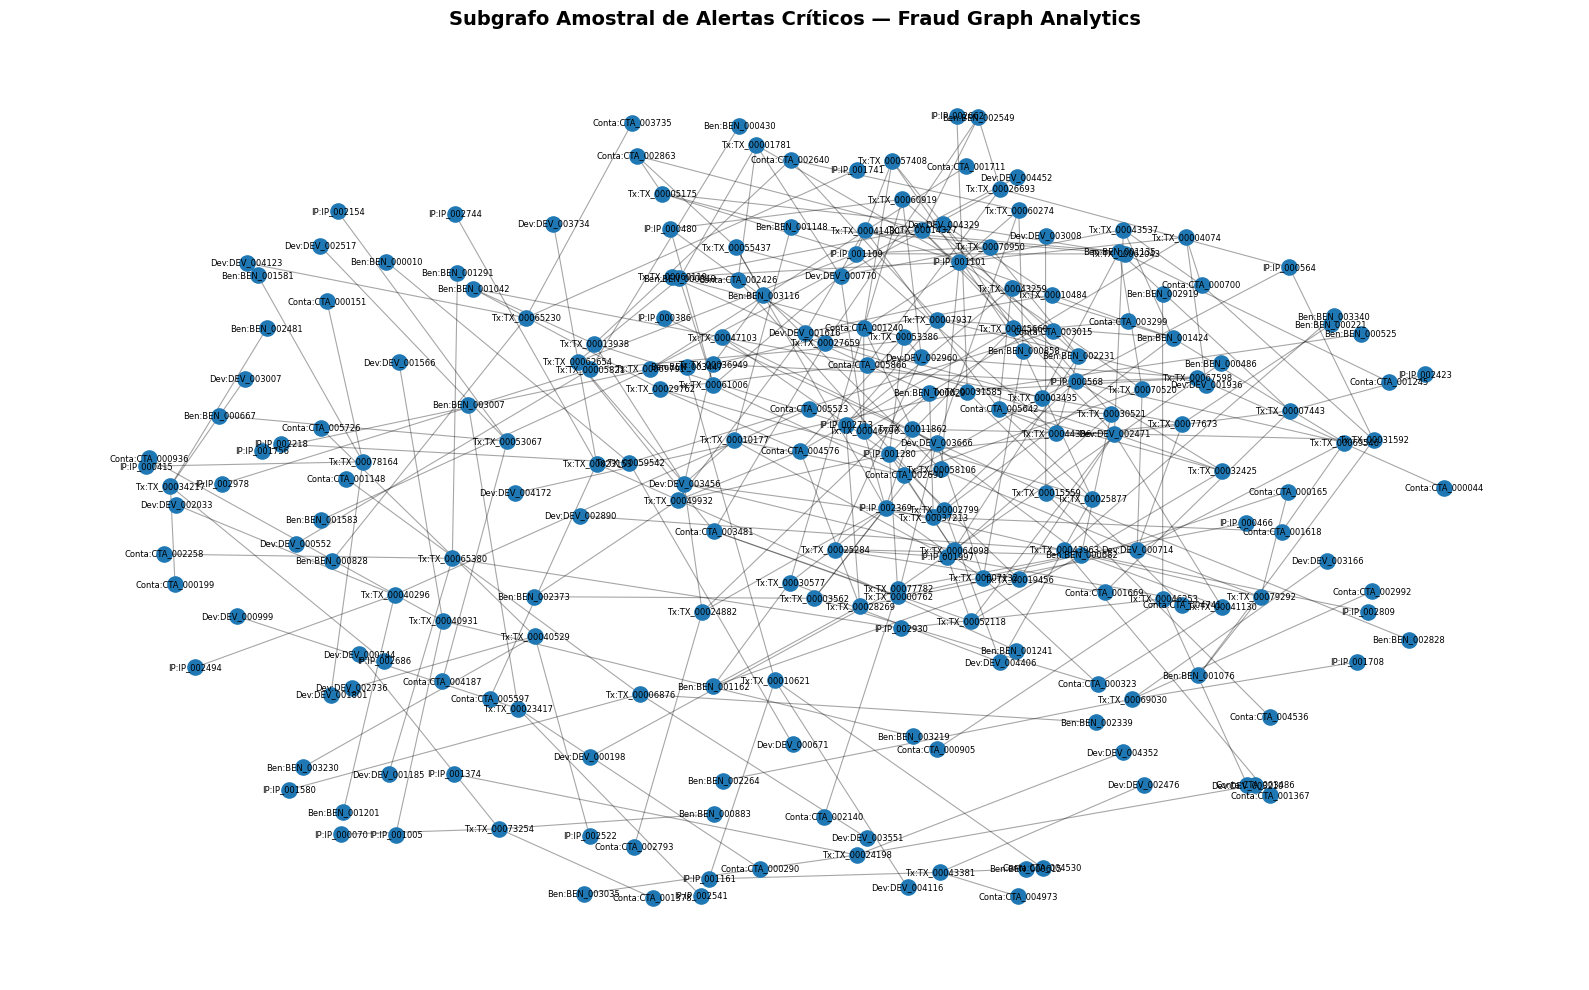

Figura salva em: d:\_DS-Projects\Data-Science\fraud-graph-analytics\artifacts\figures\neo4j_graph_model_alerts_preview.png


In [19]:
sample_alerts = (
    alerts
    .sort_values(["rule_score", "qtd_regras_acionadas", "valor"], ascending=False)
    .head(80)
    .copy()
)

G = nx.Graph()

for _, row in sample_alerts.iterrows():
    conta = f"Conta:{row['conta_origem_id']}"
    transacao = f"Tx:{row['transacao_id']}"
    beneficiario = f"Ben:{row['beneficiario_id']}"
    device = f"Dev:{row['device_id']}"
    ip = f"IP:{row['ip_id']}"
    
    G.add_node(conta, node_type="Conta")
    G.add_node(transacao, node_type="Transacao")
    G.add_node(beneficiario, node_type="Beneficiario")
    G.add_node(device, node_type="Dispositivo")
    G.add_node(ip, node_type="IP")
    
    G.add_edge(conta, transacao, relation="REALIZOU")
    G.add_edge(transacao, beneficiario, relation="ENVIOU_PARA")
    G.add_edge(transacao, device, relation="USOU")
    G.add_edge(transacao, ip, relation="ORIGINOU_DE")

plt.figure(figsize=(16, 10))

pos = nx.spring_layout(G, seed=42, k=0.4)

nx.draw_networkx_nodes(G, pos, node_size=120)
nx.draw_networkx_edges(G, pos, alpha=0.35, width=0.8)
nx.draw_networkx_labels(G, pos, font_size=6)

plt.title("Subgrafo Amostral de Alertas Críticos — Fraud Graph Analytics", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()

figure_path = FIGURES_DIR / "neo4j_graph_model_alerts_preview.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {figure_path}")

## 10. Manifesto de Carga para Neo4j

Nesta etapa será criado um manifesto documentando:

- arquivos CSV gerados;
- scripts Cypher criados;
- ordem recomendada de execução;
- observações para carga no Neo4j.

In [20]:
def safe_markdown_table(df: pd.DataFrame) -> str:
    try:
        return df.to_markdown(index=False)
    except ImportError:
        return df.to_csv(index=False)


csv_manifest = pd.DataFrame(
    [
        {
            "arquivo": path.name,
            "tipo": "node" if name.startswith("nodes_") else "relationship",
            "nome_logico": name,
            "linhas": len(node_tables.get(name, relationship_tables.get(name))),
        }
        for name, path in csv_exports.items()
    ]
).sort_values(["tipo", "arquivo"])

cypher_manifest = pd.DataFrame(
    [
        {
            "ordem": 1,
            "arquivo": "01_constraints_indexes.cypher",
            "descricao": "Cria constraints e índices.",
        },
        {
            "ordem": 2,
            "arquivo": "02_load_nodes.cypher",
            "descricao": "Carrega os nós do grafo.",
        },
        {
            "ordem": 3,
            "arquivo": "03_load_relationships.cypher",
            "descricao": "Carrega os relacionamentos do grafo.",
        },
        {
            "ordem": 4,
            "arquivo": "04_fraud_investigation_queries.cypher",
            "descricao": "Consultas investigativas iniciais.",
        },
        {
            "ordem": 5,
            "arquivo": "05_gds_algorithms.cypher",
            "descricao": "Esboço inicial para Graph Data Science.",
        },
    ]
)

manifest_lines = [
    "# Neo4j Graph Modeling — Manifesto de Carga",
    "",
    "Este documento registra os artefatos gerados pelo Notebook 04.",
    "",
    "## Arquivos CSV Gerados",
    "",
    safe_markdown_table(csv_manifest),
    "",
    "## Scripts Cypher Gerados",
    "",
    safe_markdown_table(cypher_manifest),
    "",
    "## Ordem Recomendada de Execução no Neo4j",
    "",
    "1. Copiar os arquivos CSV de `data/03-gold/neo4j_import/` para a pasta `import` do Neo4j.",
    "2. Executar `cypher/01_constraints_indexes.cypher`.",
    "3. Executar `cypher/02_load_nodes.cypher`.",
    "4. Executar `cypher/03_load_relationships.cypher`.",
    "5. Validar a carga com consultas de contagem.",
    "6. Executar `cypher/04_fraud_investigation_queries.cypher`.",
    "7. Usar `cypher/05_gds_algorithms.cypher` como base para o Notebook 05.",
    "",
    "## Observação",
    "",
    "Os CSVs são derivados dos dados sintéticos e podem ser recriados executando o notebook.",
    "Os scripts Cypher são versionáveis e documentam a estrutura de carga do Knowledge Graph.",
    "",
]

manifest_path = DOCS_DIR / "neo4j_graph_modeling_manifest.md"
manifest_path.write_text("\n".join(manifest_lines), encoding="utf-8")

print(f"Manifesto salvo em: {manifest_path}")

Manifesto salvo em: d:\_DS-Projects\Data-Science\fraud-graph-analytics\docs\neo4j_graph_modeling_manifest.md


In [21]:
graph_model_summary = pd.DataFrame(
    [
        {
            "componente": "Nós",
            "quantidade_tabelas": len(node_tables),
            "quantidade_registros": sum(len(df) for df in node_tables.values()),
            "interpretacao": "Entidades principais do domínio antifraude.",
        },
        {
            "componente": "Relacionamentos",
            "quantidade_tabelas": len(relationship_tables),
            "quantidade_registros": sum(len(df) for df in relationship_tables.values()),
            "interpretacao": "Conexões event-driven e agregadas entre entidades.",
        },
        {
            "componente": "Regras como nós",
            "quantidade_tabelas": 1,
            "quantidade_registros": len(nodes_regras),
            "interpretacao": "Permite explicar transações por regras acionadas.",
        },
        {
            "componente": "Scripts Cypher",
            "quantidade_tabelas": len(cypher_manifest),
            "quantidade_registros": len(cypher_manifest),
            "interpretacao": "Automatizam constraints, carga e consultas investigativas.",
        },
    ]
)

graph_model_summary

,componente,quantidade_tabelas,quantidade_registros,interpretacao
0,Nós,8,106010,Entidades principais do domínio antifraude.
1,Relacionamentos,10,791621,Conexões event-driven e agregadas entre entidades.
2,Regras como nós,1,10,Permite explicar transações por regras acionadas.
3,Scripts Cypher,5,5,"Automatizam constraints, carga e consultas investigativas."


In [22]:
summary_report_lines = [
    "# Graph Modeling Neo4j — Resumo Executivo",
    "",
    "Este documento consolida os principais resultados do Notebook 04.",
    "",
    "## Objetivo",
    "",
    "Transformar os dados sintéticos, transações com score e alertas antifraude em uma estrutura de Knowledge Graph compatível com Neo4j.",
    "",
    "## Síntese do Modelo",
    "",
    safe_markdown_table(graph_model_summary),
    "",
    "## Nós Gerados",
    "",
    safe_markdown_table(node_summary),
    "",
    "## Relacionamentos Gerados",
    "",
    safe_markdown_table(relationship_summary),
    "",
    "## Scripts Cypher",
    "",
    safe_markdown_table(cypher_manifest),
    "",
    "## Valor Analítico",
    "",
    "- Permite investigar conexões indiretas entre contas, dispositivos, IPs e beneficiários.",
    "- Permite explicar transações por meio das regras antifraude acionadas.",
    "- Prepara a base para algoritmos de centralidade e comunidades no Neo4j Graph Data Science.",
    "- Cria uma ponte entre regras explicáveis e análise estrutural de redes.",
    "",
    "## Próximo Passo",
    "",
    "O próximo notebook será dedicado à aplicação de algoritmos de grafo, como Degree Centrality, PageRank, Louvain e componentes conectados.",
    "",
]

summary_report_path = DOCS_DIR / "graph_modeling_neo4j_summary.md"
summary_report_path.write_text("\n".join(summary_report_lines), encoding="utf-8")

print(f"Resumo executivo salvo em: {summary_report_path}")

Resumo executivo salvo em: d:\_DS-Projects\Data-Science\fraud-graph-analytics\docs\graph_modeling_neo4j_summary.md


## 11. Conclusão Executiva do Notebook 04

Este notebook construiu a camada de **Graph Modeling** do projeto Fraud Graph Analytics.

Foram gerados:

- nós para clientes, contas, transações, beneficiários, dispositivos, IPs, cartões e regras;
- relacionamentos event-driven entre transações e entidades;
- relacionamentos agregados entre contas, dispositivos, beneficiários e IPs;
- arquivos CSV compatíveis com Neo4j;
- scripts Cypher para constraints, carga e consultas investigativas;
- manifesto de carga;
- resumo executivo da modelagem.

A modelagem em grafo permite investigar padrões que são difíceis de observar apenas em tabelas, como:

- dispositivos compartilhados por múltiplas contas;
- beneficiários concentradores;
- IPs usados por muitas contas;
- transações conectadas a múltiplas regras;
- contas com múltiplos sinais relacionais;
- estruturas candidatas a comunidades suspeitas.

O próximo passo será o:

**Notebook 05 — Graph Algorithms Fraud Detection**

Nesse notebook, o projeto avançará para análise estrutural com métricas de grafo, centralidade, comunidades e priorização de entidades suspeitas.